# 01 — EDA & Scoring
### Hormone-Immune Atlas | Exploratory Data Analysis

---

This notebook covers the full EDA pipeline:

1. **Dataset overview** — sample counts, metadata distribution
2. **Expression QC** — TPM distributions, log-transform
3. **Dimensionality reduction** — PCA colored by condition, sex, tumor stage
4. **Batch effect assessment** — PCA by sequencing run + PERMANOVA
5. **ssGSEA scoring** — hormonal pathway activation per sample
6. **Immune deconvolution** — cell type proportion estimation
7. **Score EDA** — heatmaps and differential analysis (tumor vs. normal)

> **Input:** TPM expression matrix + sample metadata + MSigDB genesets  
> **Output:** `hormone_ssgsea_scores.csv`, `immune_deconv_fractions.csv` saved to `../results/`


## 0. Imports & configuration

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
import gseapy as gp
import warnings
from scipy.stats import zscore

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths — adapt to your directory structure ────────────────────────────────
TPM_PATH_TUM      = 'data/TPM/TCGA-LUAD_2025_TumorSamples_TPM.tsv'        # genes × samples
TPM_PATH_NAT     = 'data/TPM/TCGA-LUAD_2025_NATSamples_TPM.tsv'        # genes × samples
METADATA_PATH = 'data/Metadata_Biospecimen_Clinical_TCGA2025.tsv'          # sample metadata
GENESETS_PATH = 'data/MSigDB_hormone_gene_sets_4_GSVA.tsv' # MSigDB hormonal signatures
RESULTS_DIR   = 'Output/'
FIGURES_DIR   = 'figures/'

import os
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

COND_COLORS  = {'Primary Tumor': '#e63946', 'Solid Tissue Normal': '#457b9d'}
SEX_COLORS   = {'male': '#4361ee', 'female': '#f72585'}
STAGE_COLORS = {'Stage I': '#2dc653','Stage IS': '#0000cc', 'Stage II': '#f4a261',
                'Stage III': '#e63946', 'Stage IV': '#7b2d8b', 'Unknown': '#adb5bd'}

print('✓ Imports complete')


✓ Imports complete


## 1. Data loading & dataset overview

We start by loading the TPM expression matrix and the clinical metadata.

**TPM (Transcripts Per Million)** is a normalized unit that accounts for gene length and 
sequencing depth, making samples comparable at the gene level. It is the appropriate 
starting format for both ssGSEA scoring (rank-based) and dimensionality reduction 
(after log-transformation).

### SAMPLE SELECTION FROM TCGA
 In the TCGA dataset, each patient is identified by a unique ID
 (cases.submitter_id) found in the clinical data. However, multiple biological
 samples can exist for the same patient, including both tumor tissue and
 adjacent healthy tissue.

 The biospecimen data (sample.tsv) associates each sample with:
   - a unique sample ID   →  samples.submitter_id
   - the tissue type      →  samples.specimen_type

 This allows us to trace all samples belonging to a single patient
 back to their clinical ID.

 Sample IDs follow the standard TCGA naming convention:

   **TCGA - XX - XXXX - [TYPE]**
                         
                         │
                         ├── 01  →  tumor sample
                         └── 11  →  adjacent normal tissue



In [22]:
# ── Load data ─────────────────────────────────────────────────────────────────
metadata=pd.read_csv(METADATA_PATH, sep='\t', index_col='samples.submitter_id')

tpm_tum=pd.read_csv(TPM_PATH_TUM, sep='\t',  index_col=0)       # shape: genes × samples
tpm_nat=pd.read_csv(TPM_PATH_NAT, sep='\t',  index_col=0)       # shape: genes × samples
tpm=pd.merge(tpm_tum, tpm_nat, on=['gene_id','gene_name'])
tpm_with_gene_name=tpm

# Align — keep only samples present in both
common = tpm.columns.intersection(metadata.index)
tpm      = tpm[common]
metadata = metadata.loc[common]

print(f'Expression matrix : {tpm.shape[0]:,} genes × {tpm.shape[1]:,} samples')
print(f'Metadata          : {metadata.shape[0]:,} samples × {metadata.shape[1]} features')
print(f'\nMetadata columns  : {list(metadata.columns)}')


Expression matrix : 60,660 genes × 430 samples
Metadata          : 430 samples × 9 features

Metadata columns  : ['project.project_id', 'cases.submitter_id', 'samples.sample_id', 'samples.sample_type', 'samples.specimen_type', 'samples.tumor_descriptor', 'demographic.gender', 'diagnoses.age_at_diagnosis', 'diagnoses.ajcc_pathologic_stage']


In [23]:
# ── Dataset overview table ────────────────────────────────────────────────────
# Expected metadata columns: condition (Tumor/Normal), sex (Male/Female),
#                            stage (Stage I–IV), tumor_type, run_id

summary = metadata.groupby(['project.project_id', 'samples.sample_type']).size().unstack(fill_value=0)
summary.columns.name = None
summary.index.name   = 'Tumor type'
summary['Total']     = summary.sum(axis=1)

print('\n── Sample counts per tumor type ─────────────────────────')
print(summary.to_string())
print(f'\nTotal samples : {summary["Total"].sum():,}')
print(f'  Tumor       : {summary.get("Primary Tumor", pd.Series(0)).sum():,}')
print(f'  Normal      : {summary.get("Solid Tissue Normal", pd.Series(0)).sum():,}')



── Sample counts per tumor type ─────────────────────────
            Primary Tumor  Solid Tissue Normal  Total
Tumor type                                           
TCGA-LUAD             372                   58    430

Total samples : 430
  Tumor       : 372
  Normal      : 58


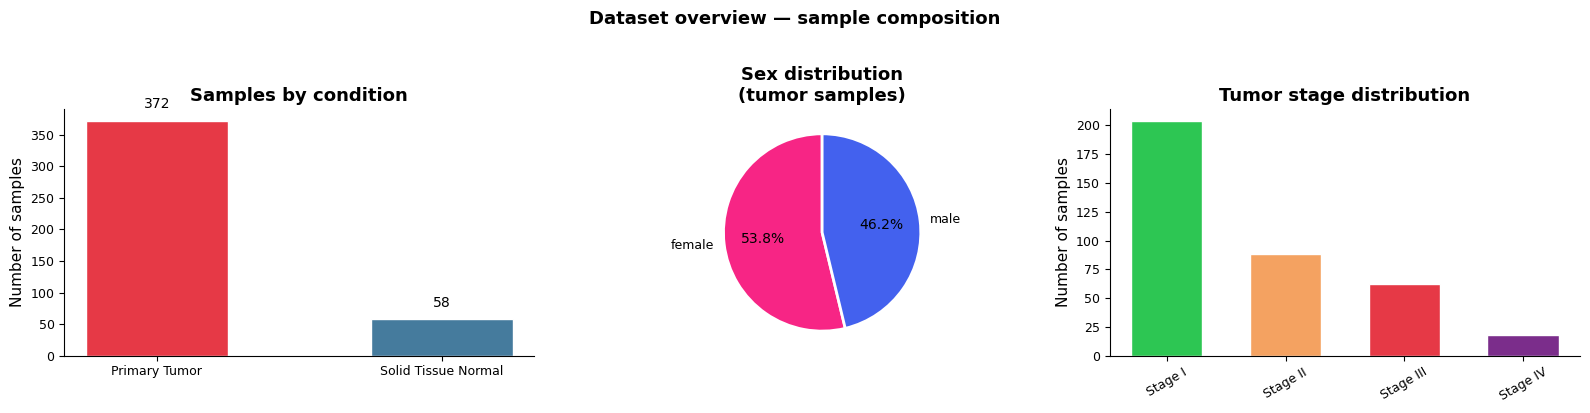

In [24]:
# ── Sex & stage distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel A — Condition breakdown
cond_counts = metadata['samples.sample_type'].value_counts()
axes[0].bar(cond_counts.index, cond_counts.values,
            color=[COND_COLORS.get(c, '#adb5bd') for c in cond_counts.index],
            edgecolor='white', width=0.5)
for i, (label, val) in enumerate(cond_counts.items()):
    axes[0].text(i, val + 20, str(val), ha='center', fontsize=10)
axes[0].set_title('Samples by condition', fontweight='bold')
axes[0].set_ylabel('Number of samples')

# Panel B — Sex distribution within tumor samples
tumor_meta = metadata[metadata['samples.sample_type'] == 'Primary Tumor']
sex_counts  = tumor_meta['demographic.gender'].value_counts()
wedge_colors = [SEX_COLORS.get(s, '#adb5bd') for s in sex_counts.index]
axes[1].pie(sex_counts.values, labels=sex_counts.index,
            colors=wedge_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sex distribution\n(tumor samples)', fontweight='bold')

# Panel C — Tumor stage distribution
stage_counts = tumor_meta['diagnoses.ajcc_pathologic_stage'].value_counts()
axes[2].bar(stage_counts.index, stage_counts.values,
            color=[STAGE_COLORS.get(s, '#adb5bd') for s in stage_counts.index],
            edgecolor='white', width=0.6)
axes[2].set_title('Tumor stage distribution', fontweight='bold')
axes[2].set_ylabel('Number of samples')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Dataset overview — sample composition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01a_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Expression distribution & normality assessment

Before choosing statistical tests for downstream analyses, we need to assess the 
distribution of expression values.

RNA-seq TPM values are **right-skewed** by nature: most genes have low expression 
while a minority are highly expressed. A log₂(TPM + 1) transformation compresses 
this skew and brings distributions closer to symmetry — but not necessarily to 
normality.

**Why this matters:** if distributions are non-normal (as expected for RNA-seq data), 
we cannot apply parametric tests (t-test, Pearson correlation). We must use 
**non-parametric alternatives** (Mann-Whitney U, Spearman correlation, Wilcoxon) 
throughout the analysis.


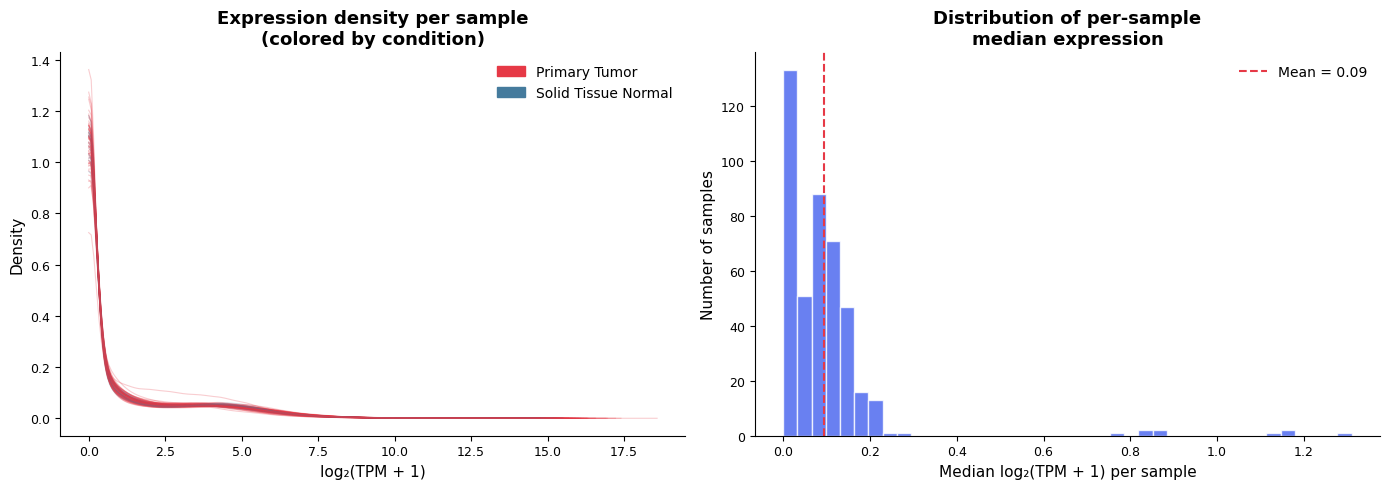

In [26]:
# ── Log-transform ─────────────────────────────────────────────────────────────
log_tpm = np.log2(tpm + 1)

# ── Subsample for visualization (avoid overplotting) ─────────────────────────
sample_cols = metadata.sample(min(80, len(metadata)), random_state=SEED).index
plot_data = log_tpm[sample_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — density per sample (colored by condition)
for col in plot_data.columns:
    
    cond   = metadata.loc[col, 'samples.sample_type']
    color  = COND_COLORS.get(cond, '#adb5bd')
    vals   = plot_data[col].dropna()
    kde_x  = np.linspace(vals.min(), vals.max(), 200)
    kde    = stats.gaussian_kde(vals)
    axes[0].plot(kde_x, kde(kde_x), color=color, alpha=0.25, linewidth=0.8)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COND_COLORS.items()]
axes[0].legend(handles=legend_patches, frameon=False)
axes[0].set_xlabel('log₂(TPM + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Expression density per sample\n(colored by condition)', fontweight='bold')

# Panel B — median expression distribution across all samples
medians = log_tpm.median(axis=0)
axes[1].hist(medians, bins=40, color='#4361ee', edgecolor='white', alpha=0.8)
axes[1].axvline(medians.mean(), color='#e63946', linestyle='--', linewidth=1.5,
                label=f'Mean = {medians.mean():.2f}')
axes[1].set_xlabel('Median log₂(TPM + 1) per sample')
axes[1].set_ylabel('Number of samples')
axes[1].set_title('Distribution of per-sample\nmedian expression', fontweight='bold')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01b_expression_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── Formal normality test (Shapiro-Wilk on subset of genes) ─────────────────
# We test a random subset of 200 genes for normality across samples.
# Shapiro-Wilk H0: the data is normally distributed.
# We expect to reject H0 for the majority of genes.

test_genes   = log_tpm.sample(200, random_state=SEED)
pvals_shapiro = []

for gene in test_genes.index:
    vals = test_genes.loc[gene].dropna().values
    if len(vals) >= 8:
        _, p = shapiro(vals[:50])   # Shapiro-Wilk limited to n≤5000; 50 is sufficient
        pvals_shapiro.append(p)

pct_normal = np.mean(np.array(pvals_shapiro) > 0.05) * 100

print(f'Shapiro-Wilk normality test on {len(pvals_shapiro)} genes:')
print(f'  Normal distribution (p > 0.05): {pct_normal:.1f}% of genes')
print(f'  Non-normal (p ≤ 0.05)         : {100-pct_normal:.1f}% of genes')
print()
print('→ Conclusion: the majority of genes deviate significantly from normality.')
print('  All downstream group comparisons will use non-parametric tests:')
print('  • Mann-Whitney U (two groups)')
print('  • Kruskal-Wallis (multiple groups)')  
print('  • Spearman correlation (instead of Pearson)')
print('  • FDR correction via Benjamini-Hochberg throughout')


Shapiro-Wilk normality test on 200 genes:
  Normal distribution (p > 0.05): 29.0% of genes
  Non-normal (p ≤ 0.05)         : 71.0% of genes

→ Conclusion: the majority of genes deviate significantly from normality.
  All downstream group comparisons will use non-parametric tests:
  • Mann-Whitney U (two groups)
  • Kruskal-Wallis (multiple groups)
  • Spearman correlation (instead of Pearson)
  • FDR correction via Benjamini-Hochberg throughout


## 3. PCA — global structure of the expression data

PCA (Principal Component Analysis) reduces ~20,000 genes to a low-dimensional 
representation that captures the main axes of variation across samples.

We use PCA to answer three questions:
1. Do **tumor and normal** samples separate? (biological signal check)
2. Do **sex** or **stage** explain additional variance? (potential confounders)
3. Does **sequencing run/batch** explain variance? (technical artifact check — see Section 4)

**Pre-processing for PCA:**
- log₂(TPM + 1) transformation (done above)
- Filter to top 5,000 most variable genes (reduces noise, speeds computation)
- StandardScaler (zero mean, unit variance) — required for PCA to avoid 
  high-expression genes dominating the components


In [28]:
# ── Select high-variance genes ────────────────────────────────────────────────
expressed = log_tpm[log_tpm.mean(axis=1) > 1]
print(f'Genes after expression filter: {len(expressed):,}')
#gene_var  = log_tpm.var(axis=1)
#top_genes = gene_var.nlargest(500).index
#log_tpm_hv = log_tpm.loc[top_genes]
gene_var  = expressed.var(axis=1)
top_genes = gene_var.nlargest(500).index
log_tpm_hv = expressed.loc[top_genes]


# Save top gene names to inspect or reuse later
top_genes_df = pd.DataFrame({
    'gene_id'  : tpm_with_gene_name[tpm_with_gene_name.index.isin(top_genes)]['gene_name'],
    'variance' : gene_var[top_genes]
}).sort_values('variance', ascending=False)

top_genes_df.to_csv('top500_genes.csv', index=False)
print(top_genes_df.head(20))    # preview the highest-variance genes

# ── PCA loadings: which genes drive each PC? ─────────────────────────────────
X = StandardScaler().fit_transform(log_tpm_hv.T)
pca = PCA(n_components=20, random_state=SEED)
pca.fit_transform(X)

# Loadings matrix: genes × PCs
loadings = pd.DataFrame(
    pca.components_.T,              # shape: n_genes × n_components
    index   = top_genes,            # gene names as index
    columns = [f'PC{i+1}' for i in range(20)]
)

# Top contributing genes per PC
for pc in ['PC1', 'PC2', 'PC3']:
    top10 = loadings[pc].abs().nlargest(10).index.tolist()
    print(f'\nTop 10 genes driving {pc}: {top10}')

loadings.to_csv('pca_loadings.csv')

print(f'Genes retained for PCA: {len(top_genes):,} (top 5,000 by variance)')

# ── Scale & compute PCA ───────────────────────────────────────────────────────
X = StandardScaler().fit_transform(log_tpm_hv.T)   # shape: samples × genes
pca = PCA(n_components=20, random_state=SEED)
pca_coords = pca.fit_transform(X)

pca_df = pd.DataFrame(pca_coords[:, :10],
                      columns=[f'PC{i+1}' for i in range(10)],
                      index=log_tpm_hv.columns)
pca_df = pca_df.join(metadata[['samples.sample_type', 'demographic.gender', 'diagnoses.ajcc_pathologic_stage']])#, 'tumor_type', 'run_id']])

explained = pca.explained_variance_ratio_ * 100
print(f'\nVariance explained:')
for i in range(5):
    print(f'  PC{i+1}: {explained[i]:.1f}%')
print(f'  Total (PC1–5): {explained[:5].sum():.1f}%')


Genes after expression filter: 17,943
                    gene_id   variance
gene_id                               
ENSG00000168484.12    SFTPC  20.931852
ENSG00000198183.12   BPIFA1  15.518000
ENSG00000129824.16   RPS4Y1  14.546560
ENSG00000096088.16      PGC  14.302272
ENSG00000149021.7   SCGB1A1  13.827294
ENSG00000122852.15   SFTPA1  13.264111
ENSG00000185303.17   SFTPA2  12.524706
ENSG00000164266.11   SPINK1  11.618268
ENSG00000171557.17      FGG  11.320748
ENSG00000066405.13   CLDN18  11.167838
ENSG00000160182.3      TFF1  11.167836
ENSG00000226278.1    PSPHP1  10.946312
ENSG00000164265.9   SCGB3A2  10.882181
ENSG00000161055.4   SCGB3A1  10.778884
ENSG00000171564.12      FGB  10.746604
ENSG00000176153.12     GPX2  10.577756
ENSG00000105388.16  CEACAM5  10.550046
ENSG00000122133.17     PAEP  10.103519
ENSG00000171560.16      FGA  10.087696
ENSG00000163993.7     S100P  10.061539

Top 10 genes driving PC1: ['ENSG00000211592.8', 'ENSG00000211896.7', 'ENSG00000244437.1', 'ENSG00000241

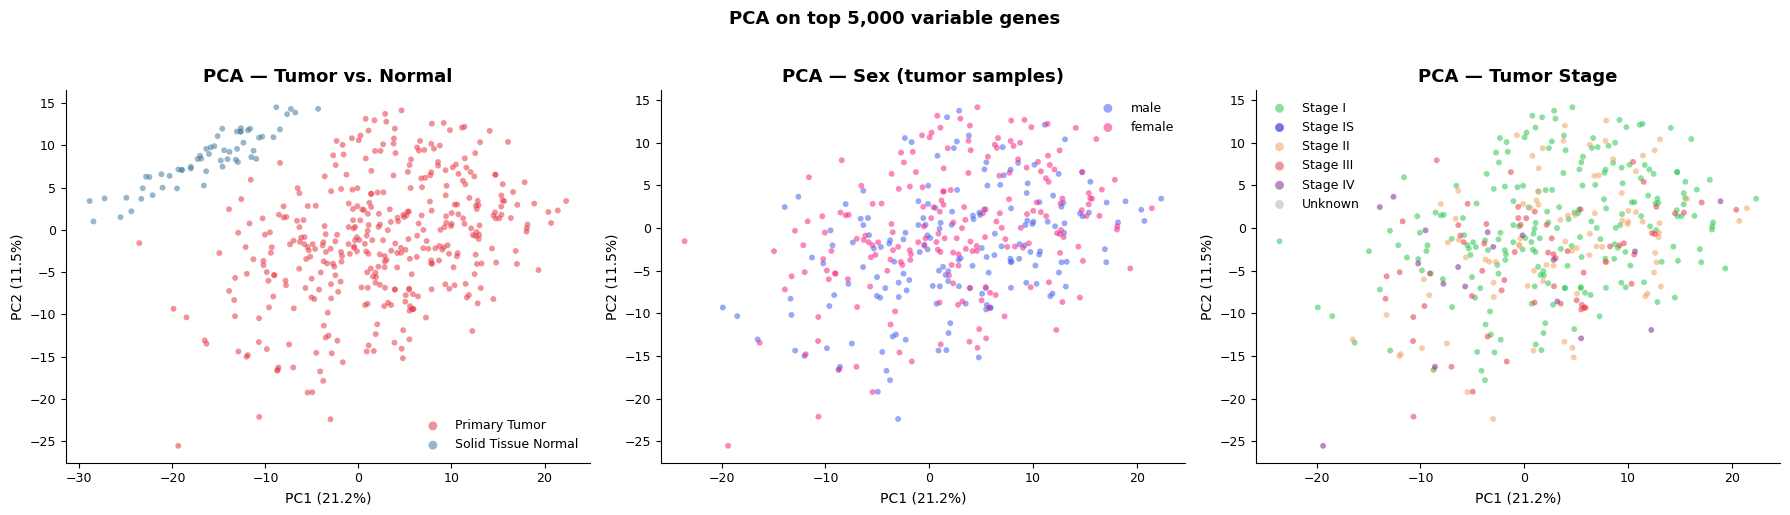

In [29]:
# ── PCA plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def scatter_pca(ax, color_col, color_map, title):
    for label, color in color_map.items():
        mask = pca_df[color_col] == label
        ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                   c=color, alpha=0.55, s=18, label=label, edgecolors='none')
    ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False, markerscale=1.5, fontsize=9)

# Panel A — by condition
scatter_pca(axes[0], 'samples.sample_type', COND_COLORS, 'PCA — Tumor vs. Normal')

# Panel B — by sex (tumor samples only)
pca_tumor = pca_df[pca_df['samples.sample_type'] == 'Primary Tumor']
for label, color in SEX_COLORS.items():
    mask = pca_tumor['demographic.gender'] == label
    axes[1].scatter(pca_tumor.loc[mask, 'PC1'], pca_tumor.loc[mask, 'PC2'],
                    c=color, alpha=0.55, s=18, label=label, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)', fontsize=10)
axes[1].set_title('PCA — Sex (tumor samples)', fontweight='bold')
axes[1].legend(frameon=False, markerscale=1.5, fontsize=9)

# Panel C — by tumor stage
for label, color in STAGE_COLORS.items():
    #print(label, color)
    mask = pca_tumor['diagnoses.ajcc_pathologic_stage'] == label
    axes[2].scatter(pca_tumor.loc[mask, 'PC1'], pca_tumor.loc[mask, 'PC2'],
                    c=color, alpha=0.55, s=18, label=label, edgecolors='none')
axes[2].set_xlabel(f'PC1 ({explained[0]:.1f}%)', fontsize=10)
axes[2].set_ylabel(f'PC2 ({explained[1]:.1f}%)', fontsize=10)
axes[2].set_title('PCA — Tumor Stage', fontweight='bold')
axes[2].legend(frameon=False, markerscale=1.5, fontsize=9)


plt.suptitle('PCA on top 5,000 variable genes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01c_pca_overview.png', dpi=150, bbox_inches='tight')
plt.show()


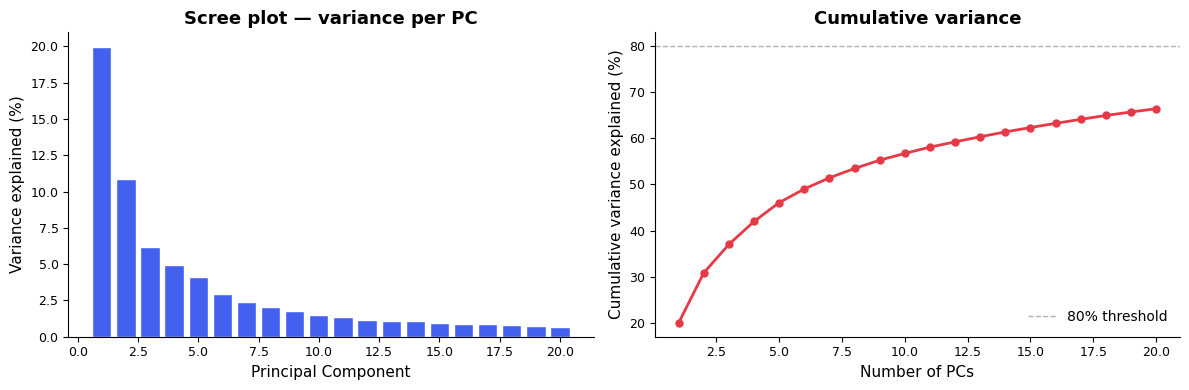

PCs needed to explain ≥80% of variance: 1


In [93]:
# ── Scree plot + PC variance summary ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 21), explained[:20], color='#4361ee', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot — variance per PC', fontweight='bold')

cumvar = np.cumsum(explained[:20])
axes[1].plot(range(1, 21), cumvar, marker='o', color='#e63946', linewidth=2, markersize=5)
axes[1].axhline(80, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='80% threshold')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative variance', fontweight='bold')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01d_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

n_pcs_80 = np.argmax(cumvar >= 80) + 1
print(f'PCs needed to explain ≥80% of variance: {n_pcs_80}')


# 4. Outlier Detection — identifying technically aberrant samples
Before any differential expression or survival analysis, we screen for samples
that are globally anomalous in gene expression space — not biologically extreme,
but technically flawed (degraded RNA, failed library prep, mislabelling).
We use **Isolation Forest**, an unsupervised anomaly detection algorithm that
identifies samples which are easier to isolate via random partitioning of the
feature space — a property of true outliers.
Detection is performed within each sample type separately (tumor vs. normal):
mixing groups would cause normal samples to appear anomalous simply by being
outnumbered, masking genuine technical failures within each condition.
Pipeline:

1. Subset expression matrix to each sample type
2. StandardScaler (zero mean, unit variance) — prevents highly expressed genes from dominating distance calculations
3. Isolation Forest (contamination=0.05) — flags the most anomalous ~5% of samples per group
4. PCA (2D) — for visualization only; outlier detection runs in full gene space
5. Flagged samples are collected and excluded from all downstream analyses

**Output**: a list of sample IDs to drop, with a PCA scatter plot showing
inliers (green) and outliers (red) for each condition.

Aligned samples: 430
samples.sample_type
Primary Tumor          372
Solid Tissue Normal     58
Name: count, dtype: int64


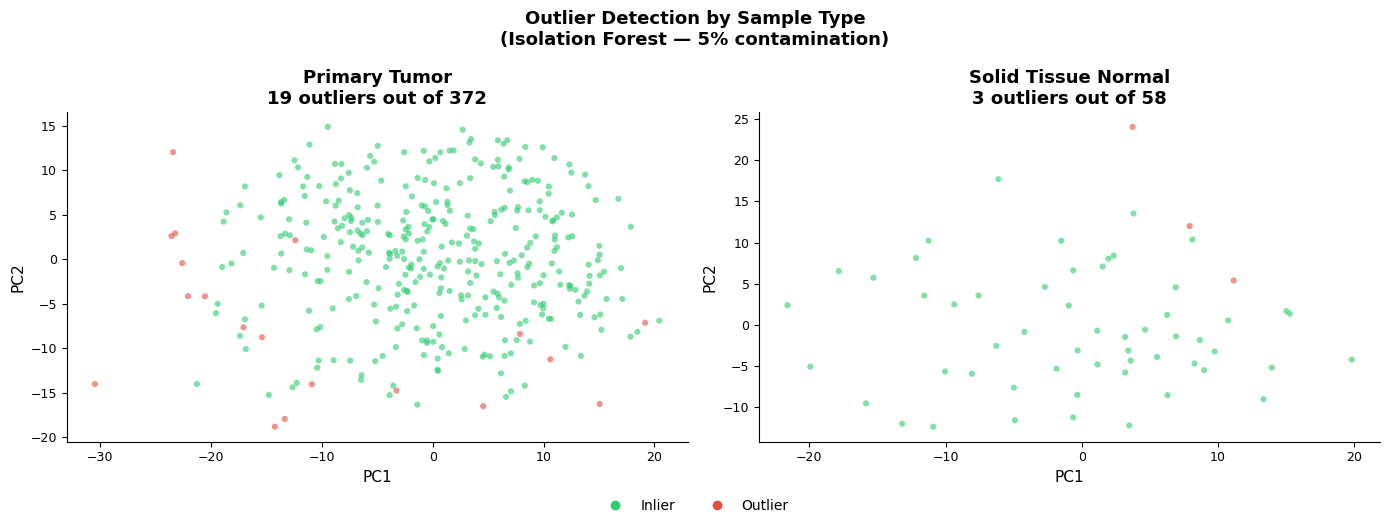


=== OUTLIER REPORT ===

Primary Tumor: 19/372 (5.1%)
          sample     score
TCGA-50-6591-01A -0.084659
TCGA-78-7633-01A -0.064461
TCGA-49-AAR9-01A -0.040018
TCGA-49-6742-01A -0.028719
TCGA-50-6590-01A -0.025344
TCGA-64-5775-01A -0.024903
TCGA-91-8496-01A -0.024210
TCGA-55-8094-01A -0.020075
TCGA-78-7155-01A -0.012909
TCGA-4B-A93V-01A -0.011818
TCGA-55-8508-01A -0.011145
TCGA-97-8179-01A -0.009004
TCGA-55-8620-01A -0.008633
TCGA-78-8662-01A -0.007741
TCGA-L9-A5IP-01A -0.005018
TCGA-78-7156-01A -0.003843
TCGA-44-7667-01A -0.003407
TCGA-78-7220-01A -0.001709
TCGA-78-7535-01A -0.000583

Solid Tissue Normal: 3/58 (5.2%)
          sample     score
TCGA-91-6835-11A -0.018497
TCGA-55-6985-11A -0.010948
TCGA-49-4512-11A -0.002279

Total samples flagged for removal: 22


In [30]:
X = log_tpm_hv.T  # transpose → rows = samples, columns = genes

# Keep only samples present in both dataframes
common = X.index.intersection(metadata.index)
X = X.loc[common]
meta = metadata.loc[common]

print(f"Aligned samples: {len(common)}")
print(meta['samples.sample_type'].value_counts())

# ── Outlier detection per condition ───────────────────────────────────────────
# Outliers are detected within each sample type separately.
# A sample is anomalous relative to its own group, not to the entire dataset.
# Mixing tumor and normal would cause normal samples to appear as outliers
# simply because they are outnumbered, not because they are technically flawed.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import pandas as pd

results = []

for condition, group in meta.groupby('samples.sample_type'):
    
    sample_ids = group.index
    X_group = X.loc[sample_ids]
    
    # Standardize: bring each gene to mean=0, std=1
    # Prevents highly expressed genes from dominating the analysis
    X_scaled = StandardScaler().fit_transform(X_group)
    
    # PCA for 2D visualization only — outliers are detected in full gene space
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_ * 100
    
    # Isolation Forest: anomalous samples are easier to isolate with random cuts
    # contamination=0.05 → expects ~5% outliers per group (conservative estimate)
    iso = IsolationForest(contamination=0.05, random_state=42)
    labels = iso.fit_predict(X_scaled)       # -1 = outlier, 1 = inlier
    scores = iso.decision_function(X_scaled) # lower score = more anomalous
    
    df_group = pd.DataFrame({
        'PC1': coords[:, 0],
        'PC2': coords[:, 1],
        'outlier': labels == -1,
        'score': scores,
        'sample': sample_ids,
        'condition': condition
    })
    results.append(df_group)

pca_df = pd.concat(results, ignore_index=True)

# ── Plot: one panel per sample type ───────────────────────────────────────────
conditions = pca_df['condition'].unique()
fig, axes = plt.subplots(1, len(conditions), figsize=(7 * len(conditions), 5))
if len(conditions) == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    subset = pca_df[pca_df['condition'] == condition]
    colors = subset['outlier'].map({True: '#e74c3c', False: '#2ecc71'})
    ax.scatter(subset['PC1'], subset['PC2'],
               c=colors, alpha=0.6, s=20, edgecolors='none')
    n_out = subset['outlier'].sum()
    ax.set_title(f'{condition}\n{n_out} outliers out of {len(subset)}', fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Add a shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=8, label='Inlier'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Outlier')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Outlier Detection by Sample Type\n(Isolation Forest — 5% contamination)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01e_outlier_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Outlier report ─────────────────────────────────────────────────────────────
print("\n=== OUTLIER REPORT ===")
for condition, group in pca_df.groupby('condition'):
    outliers = group[group['outlier']].sort_values('score')
    print(f"\n{condition}: {len(outliers)}/{len(group)} ({len(outliers)/len(group)*100:.1f}%)")
    print(outliers[['sample', 'score']].to_string(index=False))

# Final list of samples to exclude from downstream analyses
outlier_samples = pca_df[pca_df['outlier']]['sample'].tolist()
print(f"\nTotal samples flagged for removal: {len(outlier_samples)}")

# To filter them out:
expr_clean = log_tpm_hv.drop(columns=outlier_samples)
meta_clean = meta.drop(index=outlier_samples)

In [32]:
expr_clean_samples=list(expr_clean.columns)

tpm_with_gene_name[['gene_name']+expr_clean_samples].to_csv('data/TPM/NO_outlier/TCGA-LUAD_2025_TumorSamples&NATSamples_TPM_No_outlier.tsv', sep='\t', index=None)


## 5. EDA summary & decisions for downstream analysis

| Observation | Decision |
|---|---|
| TPM distributions are right-skewed, most genes non-normal (Shapiro-Wilk) | Use **non-parametric tests** throughout (Mann-Whitney U, Spearman, Kruskal-Wallis) |
| PCA shows clear tumor vs. normal separation on PC1–2 | Biological signal is strong; condition is the dominant source of variance |
| Outlier detection | Identifies samples to be removed from further analyses

---
*Next: `02_ssgsea_calculation_AND_immune_deconvolution.ipynb` — ssgsea score calculation for hormone signatures AND immune decolvolution on RNA-seq data to estimate the immune cells proportions in normal and tumor samples*
